In [10]:
import anndata as ad
import h5py
import scvelo as scv
import warnings
import matplotlib.pyplot as plt


In [2]:
scv.settings.verbosity = 3  
scv.settings.presenter_view = True 
scv.set_figure_params('scvelo') 
scv.settings.figdir = "/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/figures/"
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
adata = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/raw/combined_adata_raw_2.h5ad")
adata_subset = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/combined_epi_adata_clustered_(30,27)_(0.5,1)_8_5_25.h5ad")

In [4]:
glasbey_clean_24 = [
    "#E41A1C",  # Red
    "#377EB8",  # Blue
    "#4DAF4A",  # Green
    "#984EA3",  # Purple
    "#FF7F00",  # Orange
    "#FFFF33",  # Yellow
    "#A65628",  # Brown
    "#F781BF",  # Pink
    "#999999",  # Gray
    "#66C2A5",  # Teal
    "#FC8D62",  # Coral
    "#8DA0CB",  # Muted blue
    "#E78AC3",  # Light pink
    "#A6D854",  # Lime
    "#FFD92F",  # Yellow-orange
    "#E5C494",  # Tan
    "#B3B3B3",  # Light gray
    "#1B9E77",  # Deep teal
    "#D95F02",  # Burnt orange
    "#7570B3",  # Muted violet
    "#E7298A",  # Vivid pink
    "#66A61E",  # Olive green
    "#E6AB02",  # Goldenrod
    "#A6761D"   # Rich brown
]

In [5]:
adata_raw = adata.copy() 
adata_raw = adata_raw[adata_subset.obs_names, :].copy()
adata_raw = adata_raw[:, adata_subset.var_names].copy()
adata_raw.obsm["X_umap"] = adata_subset.obsm["X_umap"]
adata_raw.obs["leiden"]  = adata_subset.obs["leiden"]

In [5]:
#adata_velocity=adata_subset.copy()

In [6]:
adata_raw

AnnData object with n_obs × n_vars = 4655 × 2000
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [7]:
adata_subset

AnnData object with n_obs × n_vars = 4655 × 2000
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'scrublet_score_zscore_0p04_pc35', 'scrublet_pred_zscore_0p04_pc35', 'scrublet_score_zscore_0p06_pc35', 'scrublet_pred_zscore_0p06_pc35', 'scrublet_score_zscore_0p08_pc35', 'scrublet_pred_zscore_0p08_pc35', 'scrublet_score_zscore_0p1_pc35', 'scrublet_pred_zscore_0p1_pc35', 'scrublet_score_zscore_0p04_pc40', 'scrublet_pred_zscore_0p04_pc40', 'scrublet_score_zscore_0p06_pc40', 'scrublet_pred_zscore_0p06_pc40', 'scrublet_score_zscore_0p08_pc40', 'scrublet_pred_zscore_0p08_pc40', 'scrublet_score_zscore_0p1_pc40', 'scrublet_pred_zscore_0p1_pc40', 'scrublet_score_zscore_0p04_pc45', 'scrublet_pred_zscore_0p04_pc45', 'scrublet_score_zscore_0p06_pc45', 'scrublet_pred_zscore_0p06_pc45', 'scrublet_score_zscore_0p0

In [6]:
adata_velocity=adata_raw.copy()

In [14]:
adata_velocity

AnnData object with n_obs × n_vars = 4655 × 2000
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden'
    obsm: 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

Filtered out 593 genes that are detected 20 counts (spliced).
Normalized count data: X, spliced, unspliced.


/scratch/local/9688662/ipykernel_3630698/1367128501.py:9: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_velocity, n_pcs=24, n_neighbors=36)
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/128 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


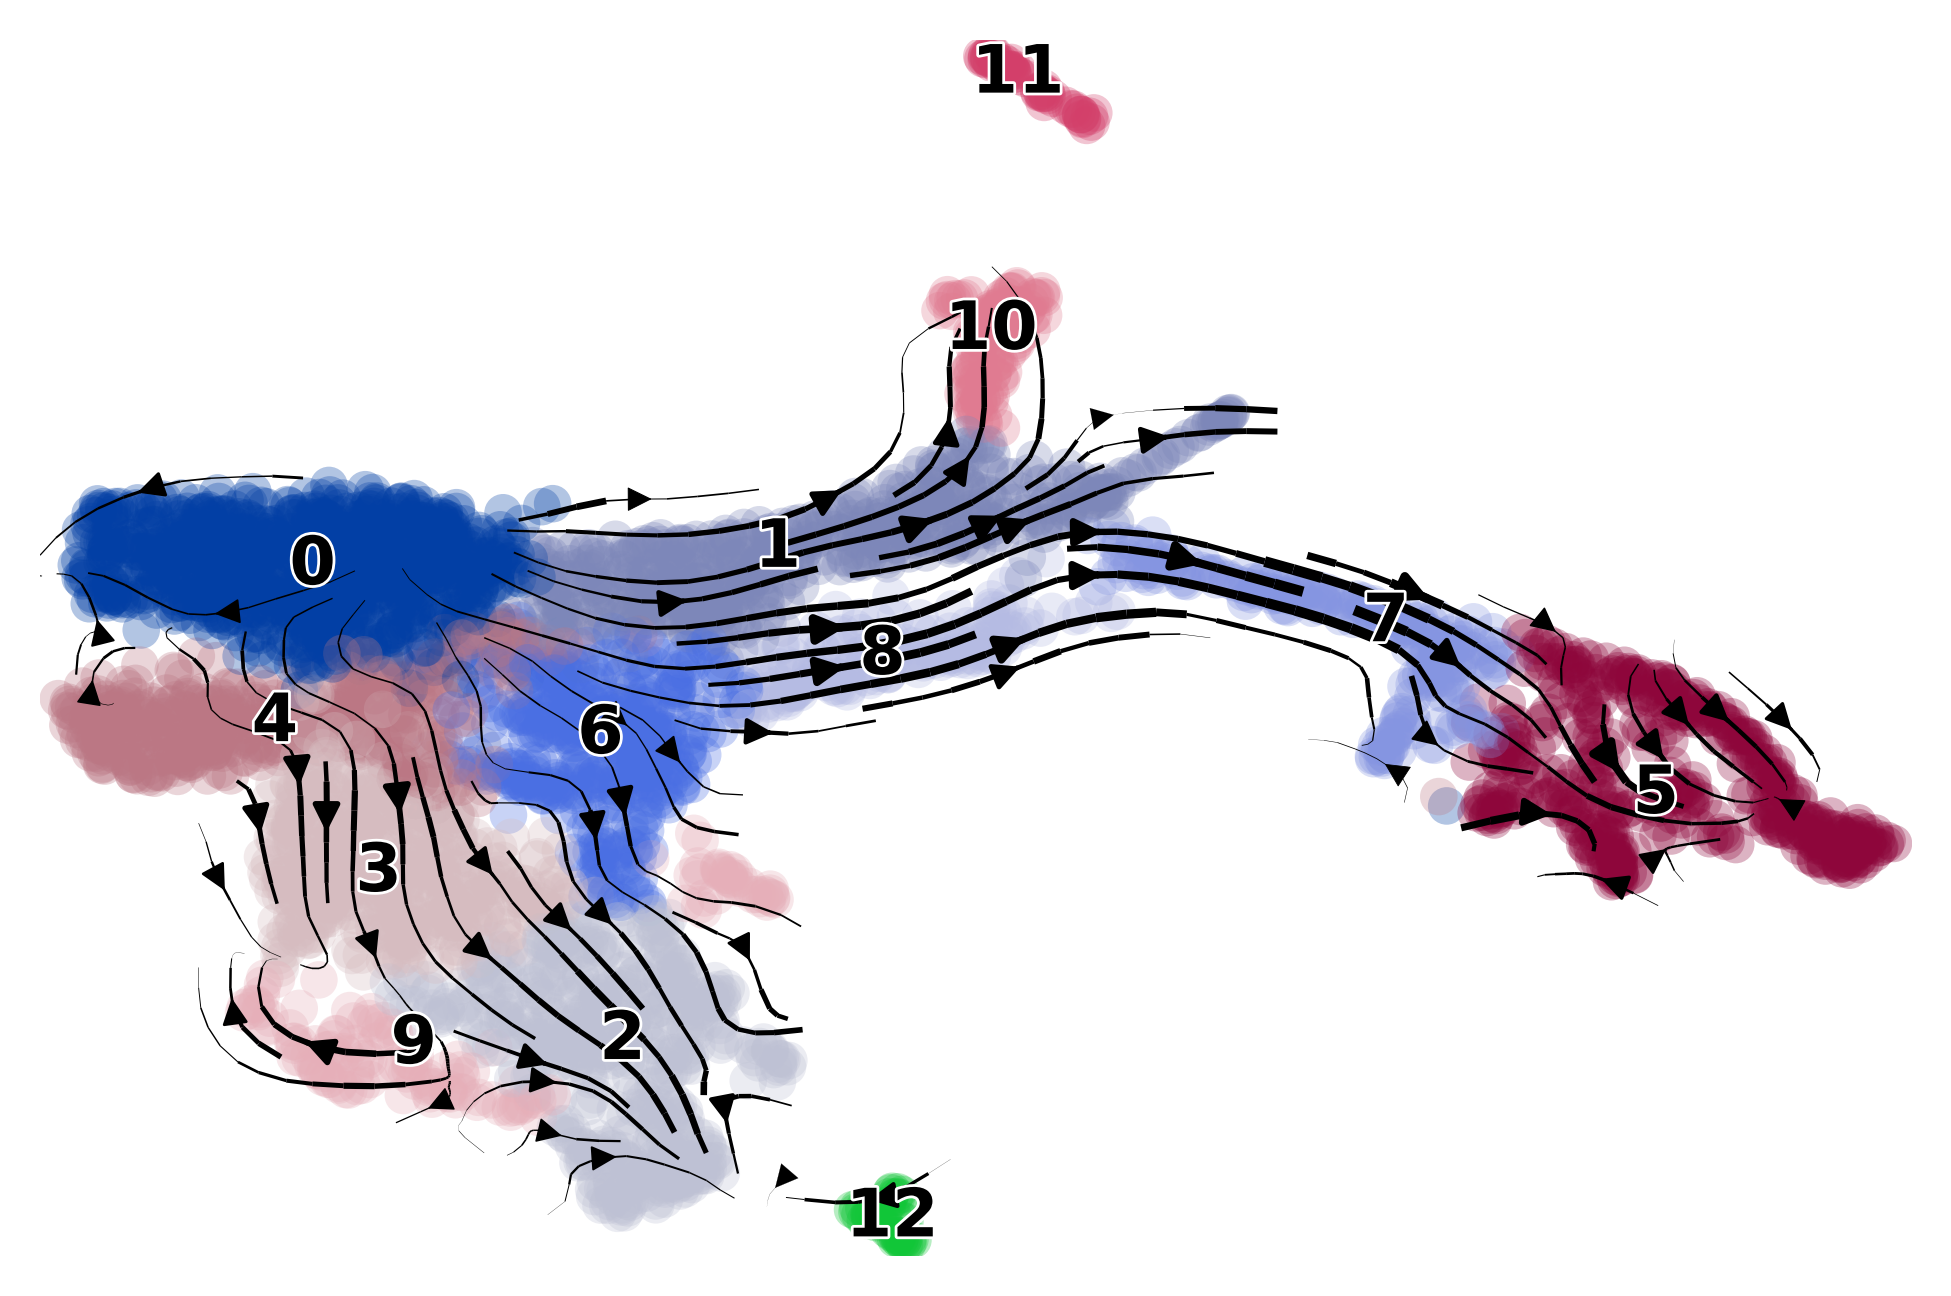

In [7]:
adata_velocity=adata_raw.copy()
scv.pp.filter_and_normalize(
    adata_velocity,
    min_counts=20,
    min_cells=5,
    n_top_genes=None, 
    log=False
)
scv.pp.moments(adata_velocity, n_pcs=24, n_neighbors=36)
#scv.tl.recover_dynamics(adata_velocity, n_jobs=8)
scv.tl.velocity(adata_velocity, mode="stochastic", n_jobs=8)
scv.tl.velocity_graph(adata_velocity, n_jobs=8)
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=200,color="leiden", title="",
                                 #save="plus345_2_subset_velocity_stream_grey.svg"
                                )

In [8]:
import os
os.chdir("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/figures")

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


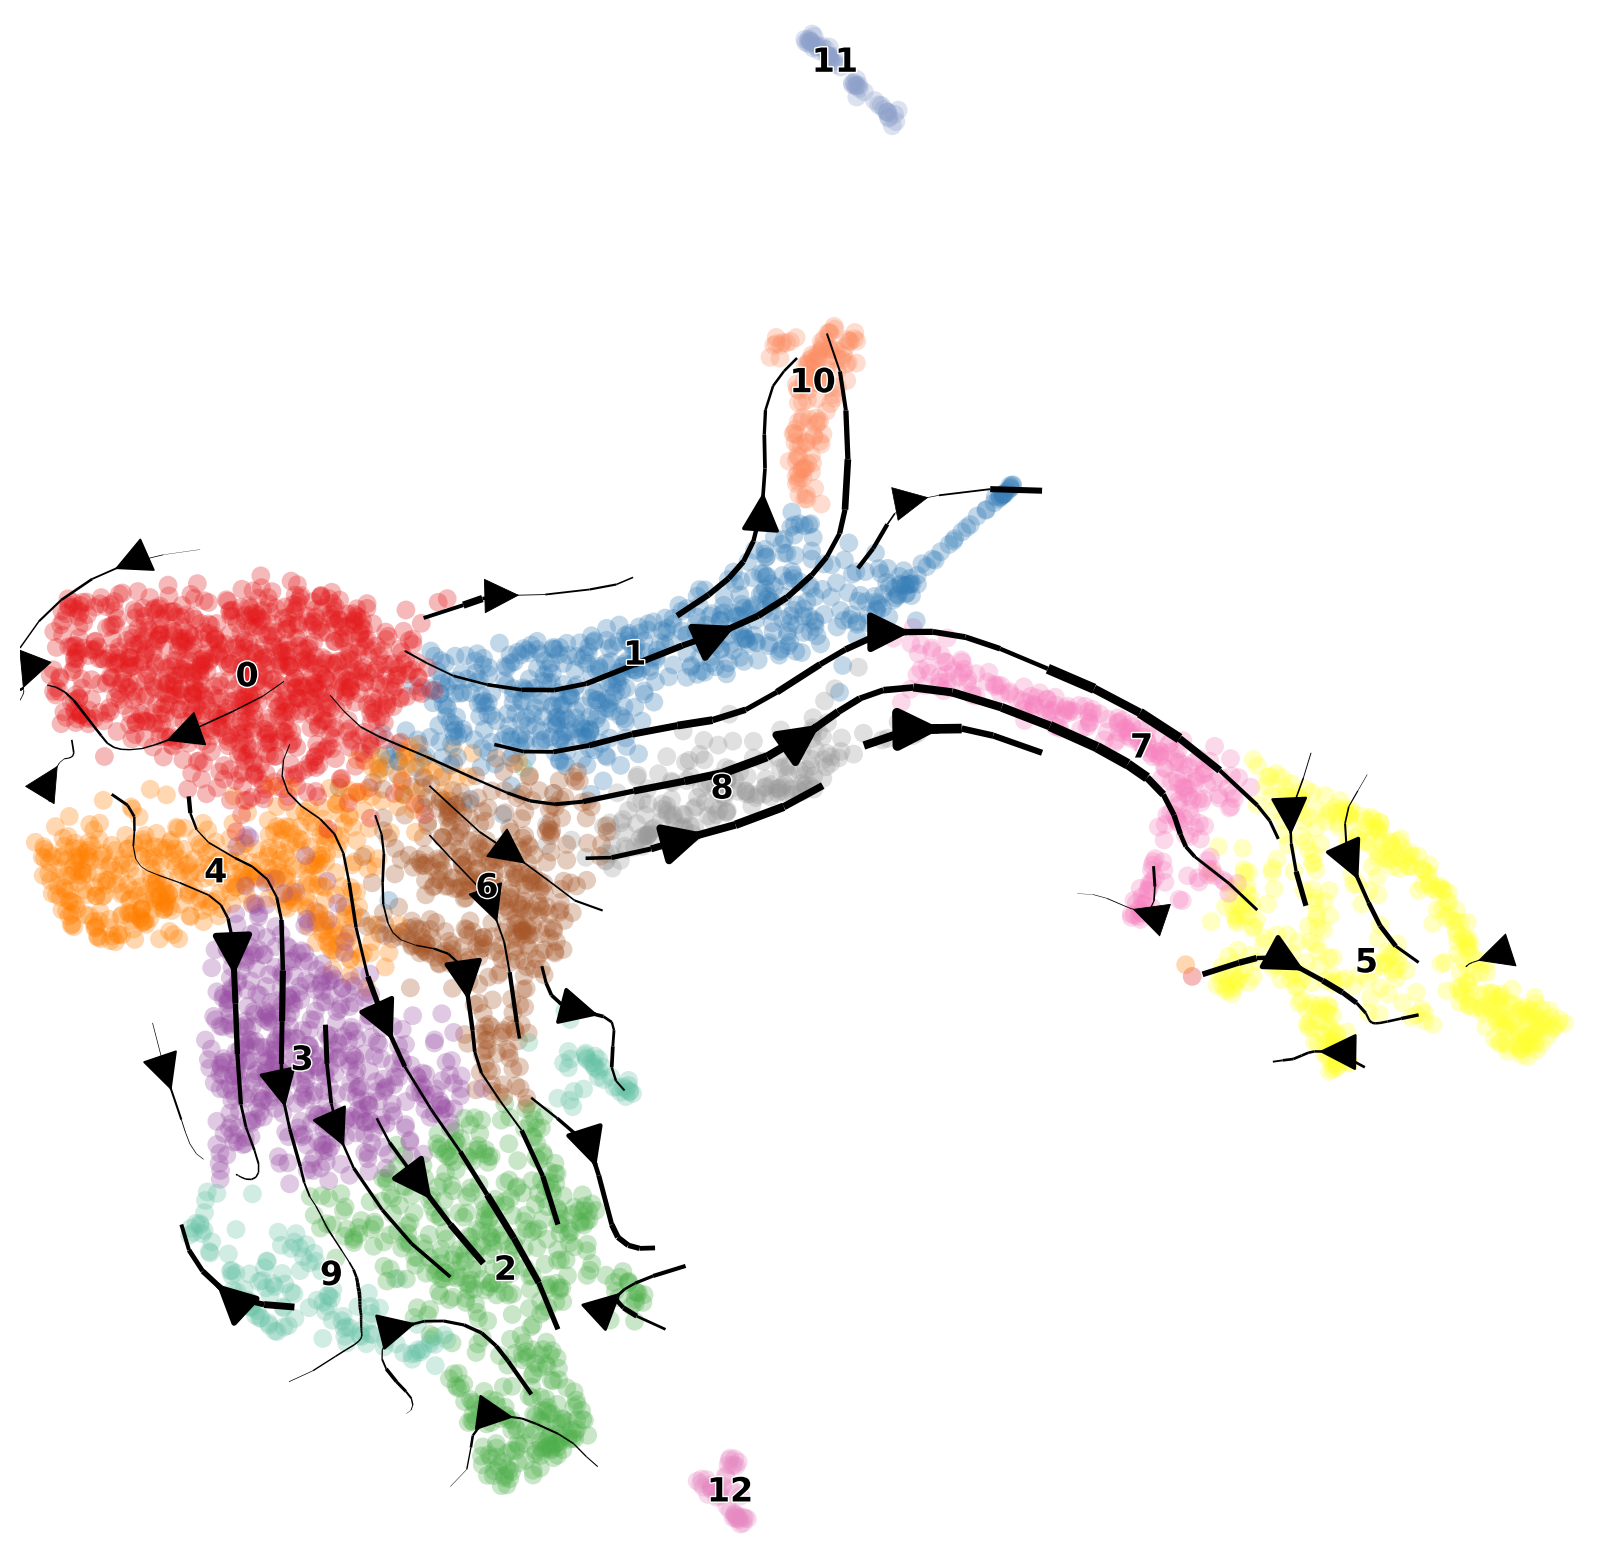

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
scv.pl.velocity_embedding_stream(
    adata_velocity,
    basis="umap",
    color="leiden",
    title="",
    density=1,
    ax=ax,
    show=False,
    arrow_size=3,
    linewidth=2,
    palette=glasbey_clean_24
)

# Choose ONE of these saves:

# 1) No cropping (exact figure size)
fig.savefig("velo_all_epi_thick_(30,27)_(0.5,1)_8_5_25.svg", dpi=300)


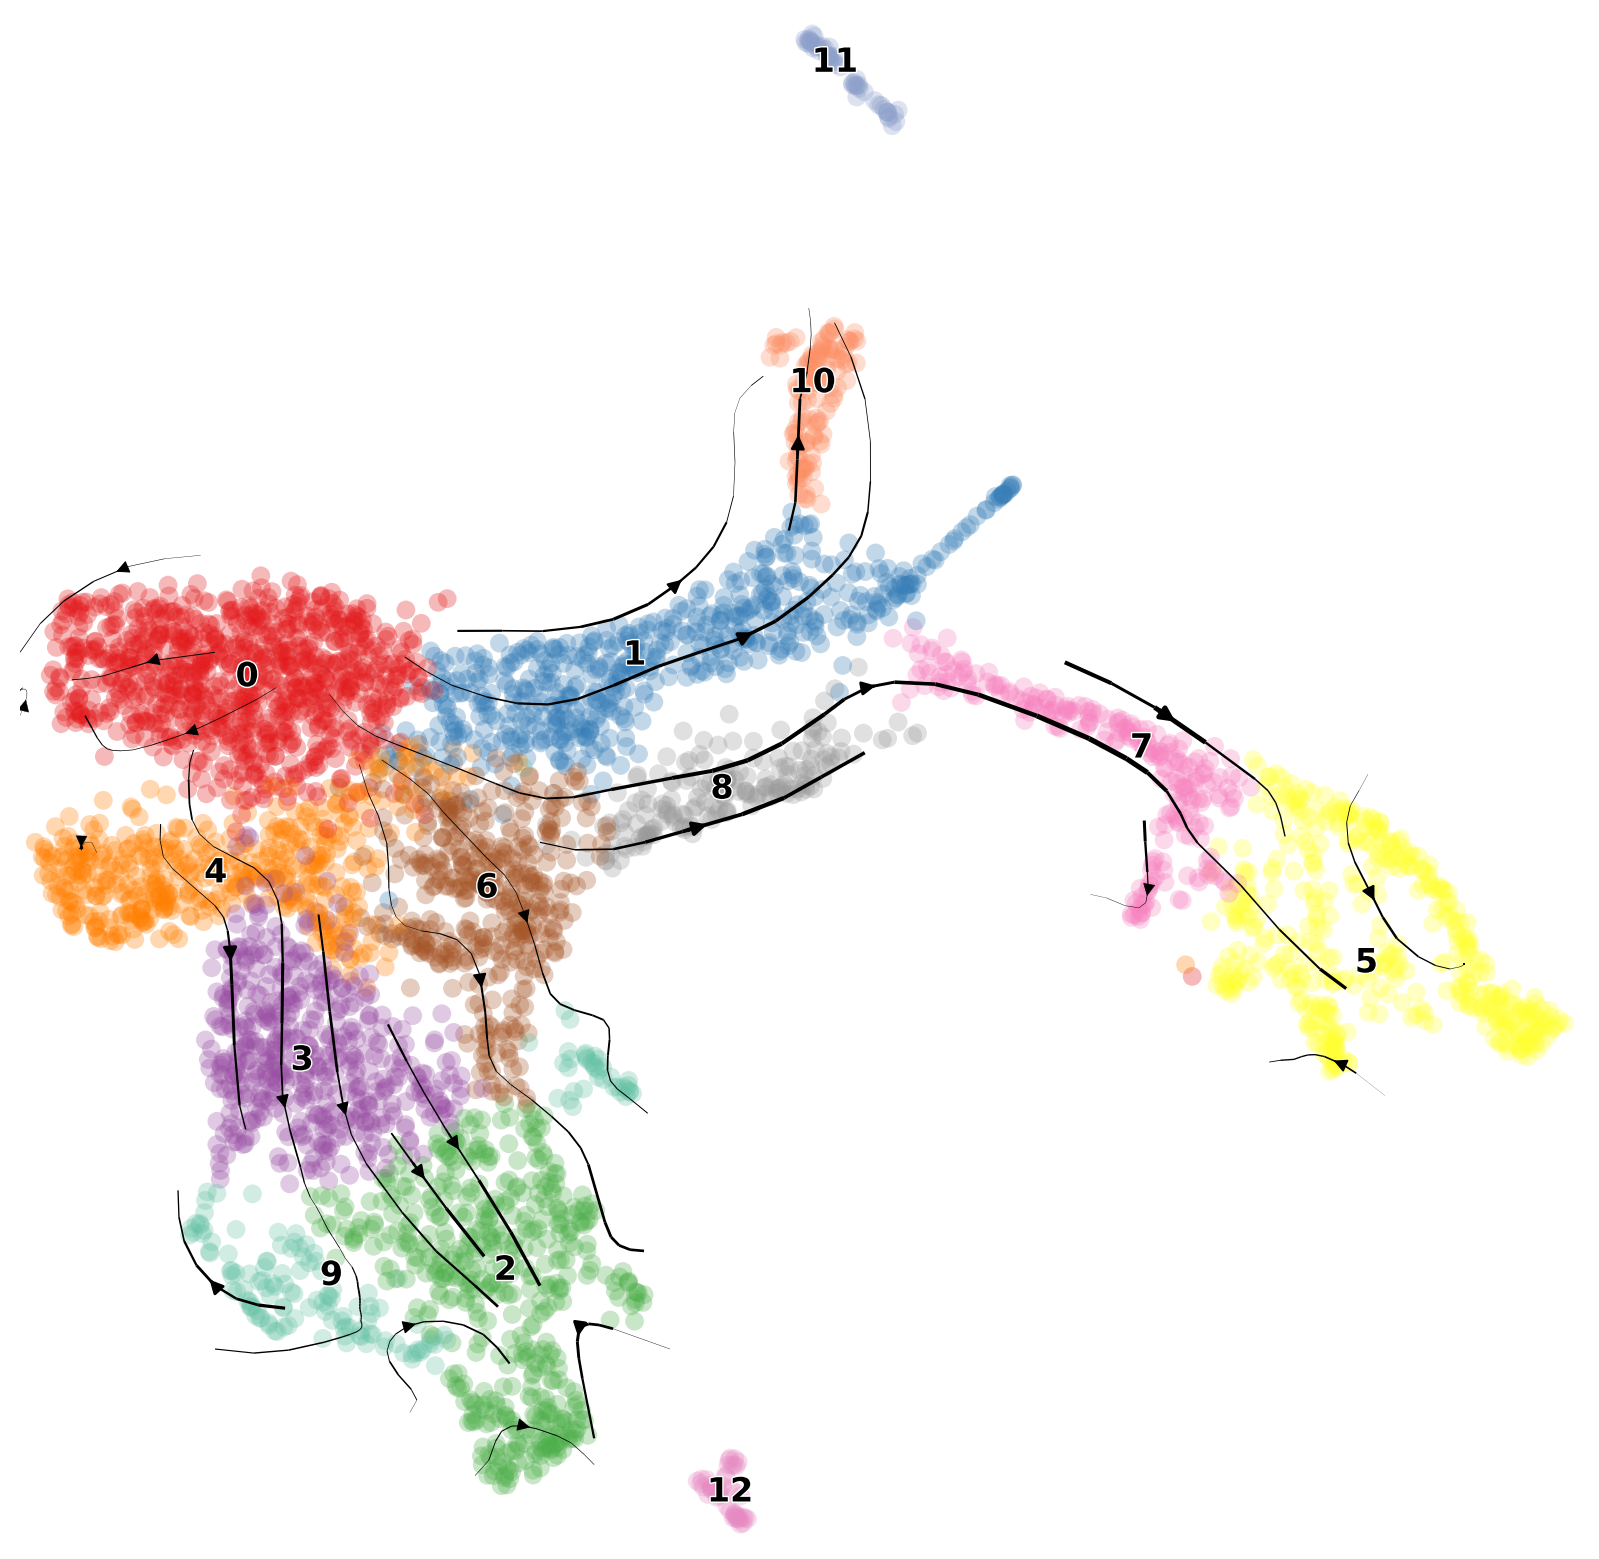

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))
scv.pl.velocity_embedding_stream(
    adata_velocity,
    basis="umap",
    color="leiden",
    title="",
    density=0.85,
    ax=ax,
    show=False
)

# Choose ONE of these saves:

# 1) No cropping (exact figure size)
fig.savefig("velo_box_all_epi_subset_combined_(30,27)_(0.5,1)_8_5_25.svg", dpi=300)

# 2) Tight crop (helps with arrowheads getting cut off)
# fig.savefig("velo_box_all_epi_subset_combined_(30,27)_(0.5,1)_8_5_25.svg",
#             dpi=300, bbox_inches="tight", pad_inches=0.1)

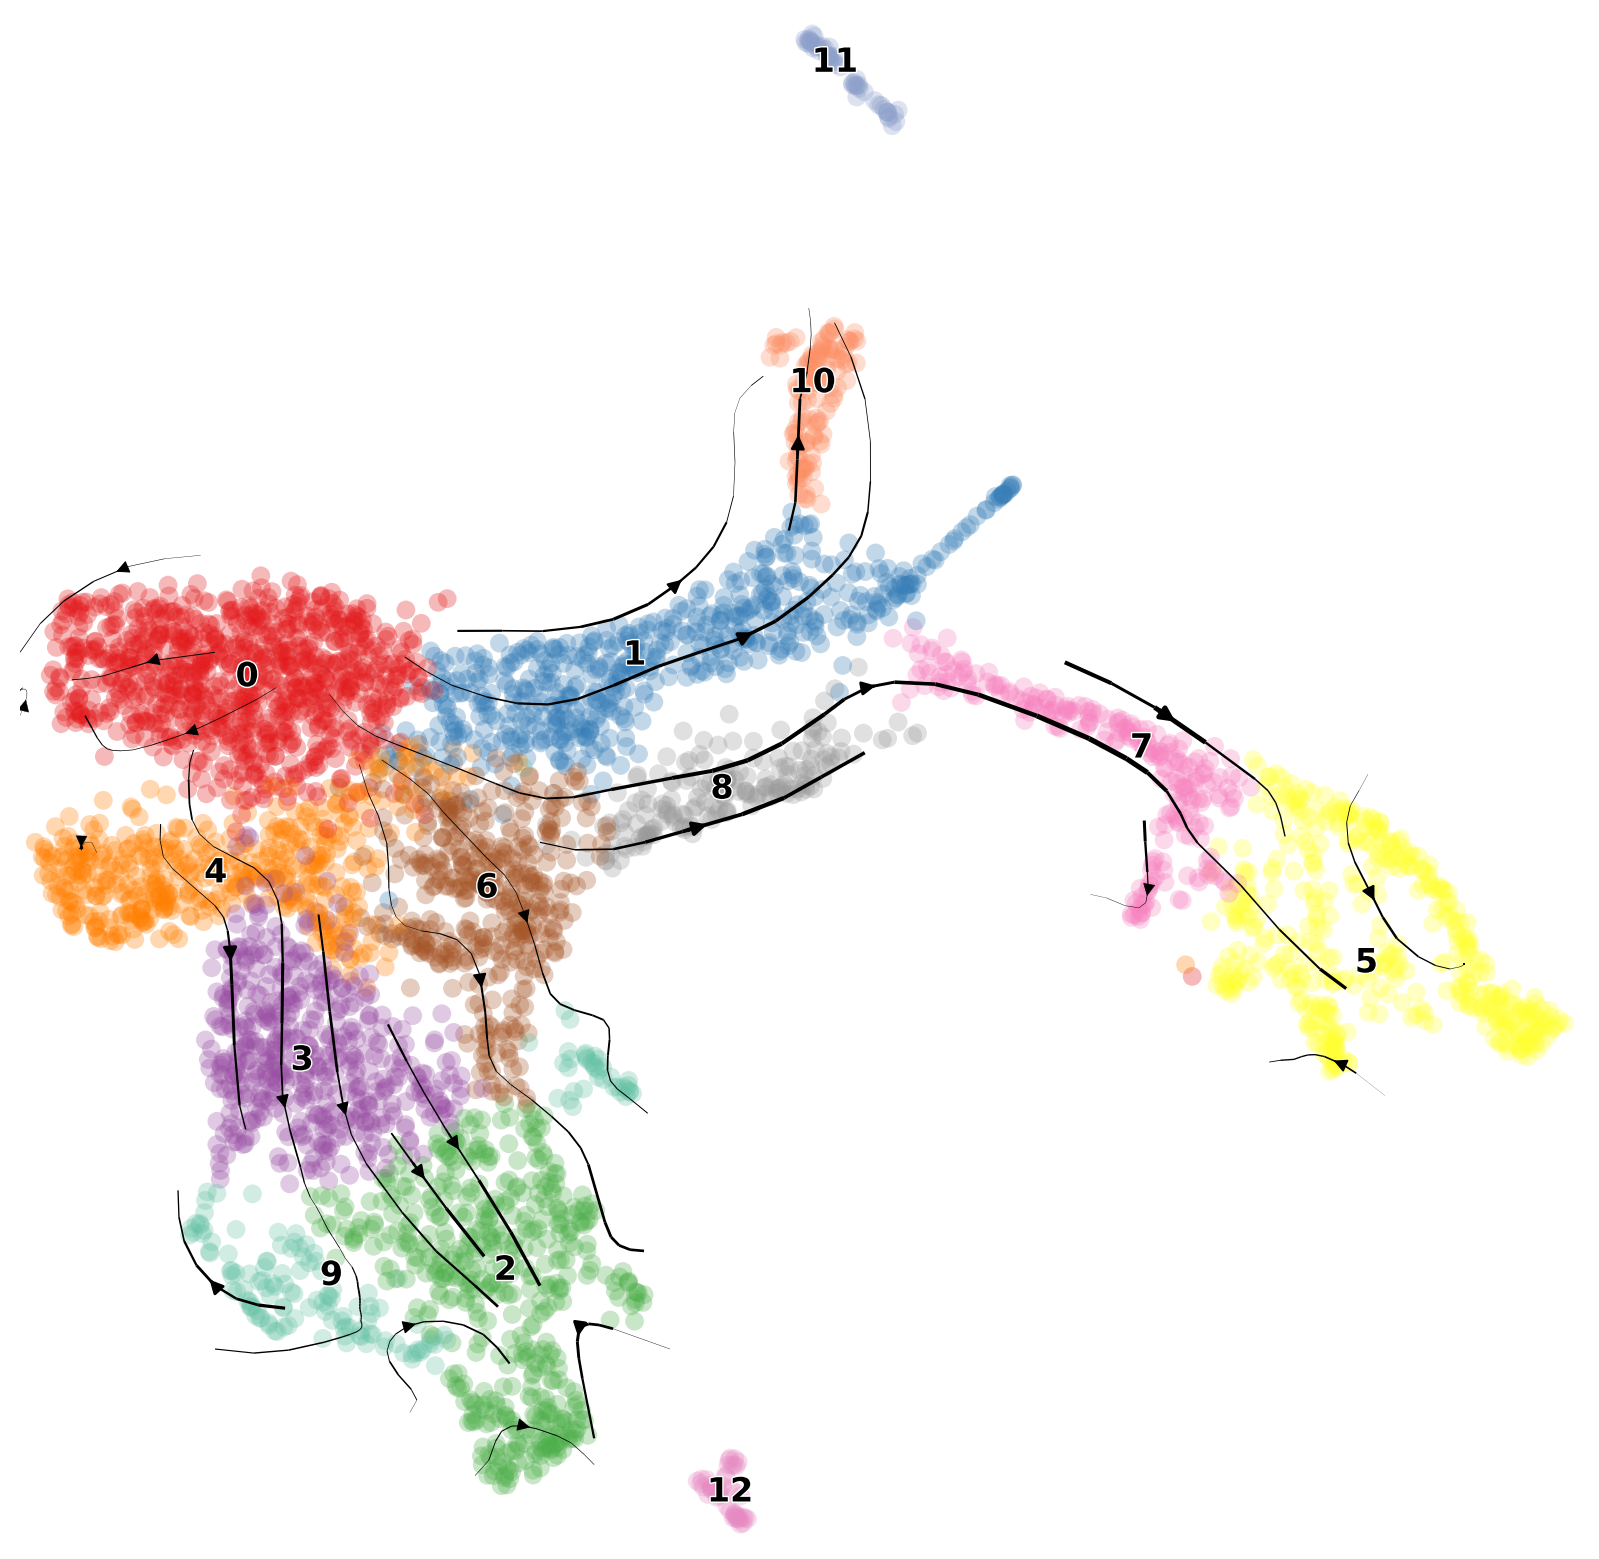

In [37]:
import matplotlib.pyplot as plt
import scvelo as scv

# Optional: set figure size here
plt.rcParams["figure.figsize"] = (6, 6)

# Create plot and capture the matplotlib axis
fig, ax = plt.subplots(figsize=(10, 10))

scv.pl.velocity_embedding_stream(
    adata_velocity,
    basis="umap",
    color="leiden",
    title="",
    palette=glasbey_clean_24,
    ax=ax,
    density=.85,
    show=False  # prevents auto-display and lets you save manually
)

# Now save manually with tight bounding box
fig.savefig("_all_epi_subset_combined.svg", dpi=300, bbox_inches="tight")

saving figure to file /blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/figures/scvelo__velo_all_epi_subset_combined_({n_pcs},{n_neighbors})_({min_dist},{spread}.svg


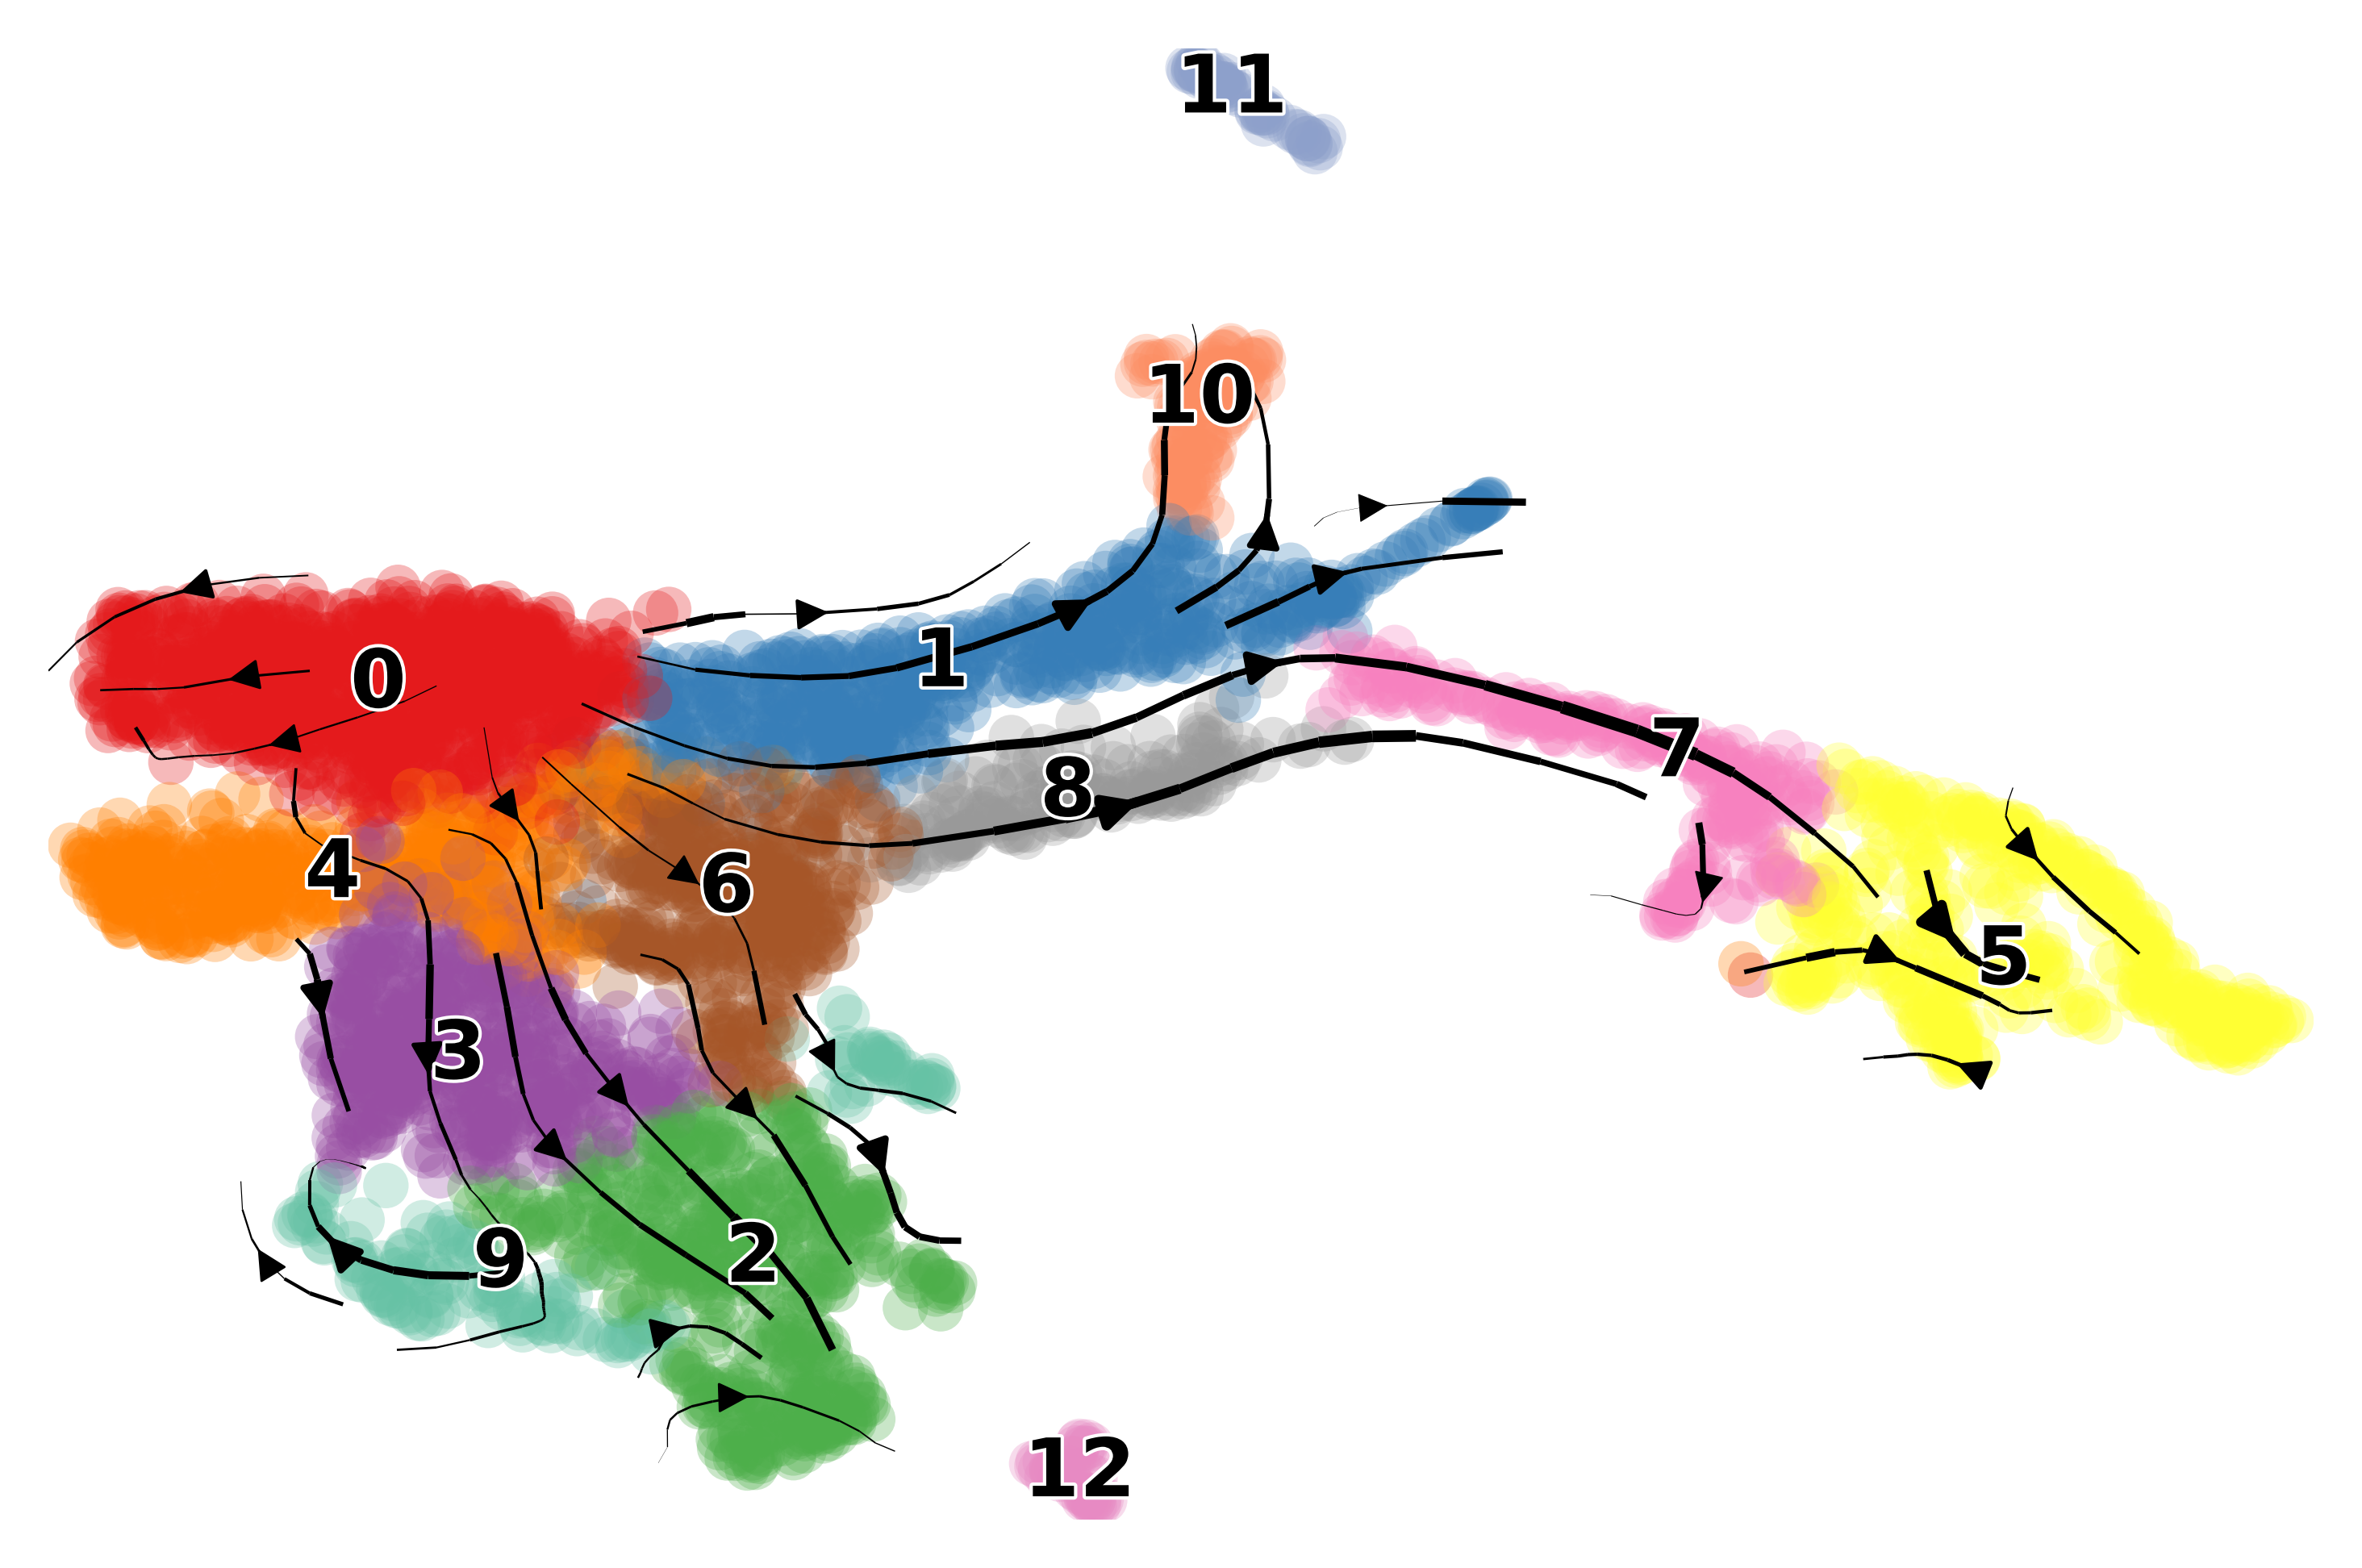

In [30]:
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=300,color="leiden", title="",palette=glasbey_clean_24,density=.9,
                                 save="_velo_all_epi_subset_combined_({n_pcs},{n_neighbors})_({min_dist},{spread}.svg"
                                )

In [16]:
adata_velocity.write(f"/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/combined_epi_velo_(30,27)_(0.5,1)_8_5_25.h5ad")

In [ ]:
adata_velocity = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/adata_subset_velocity_final_1.h5ad")
#adata_velocity = ad.read_h5ad("/blue/square.t/peter.huynh/jupyter/combined_samples_scvelo/data/processed/adata_velocity.h5ad")

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


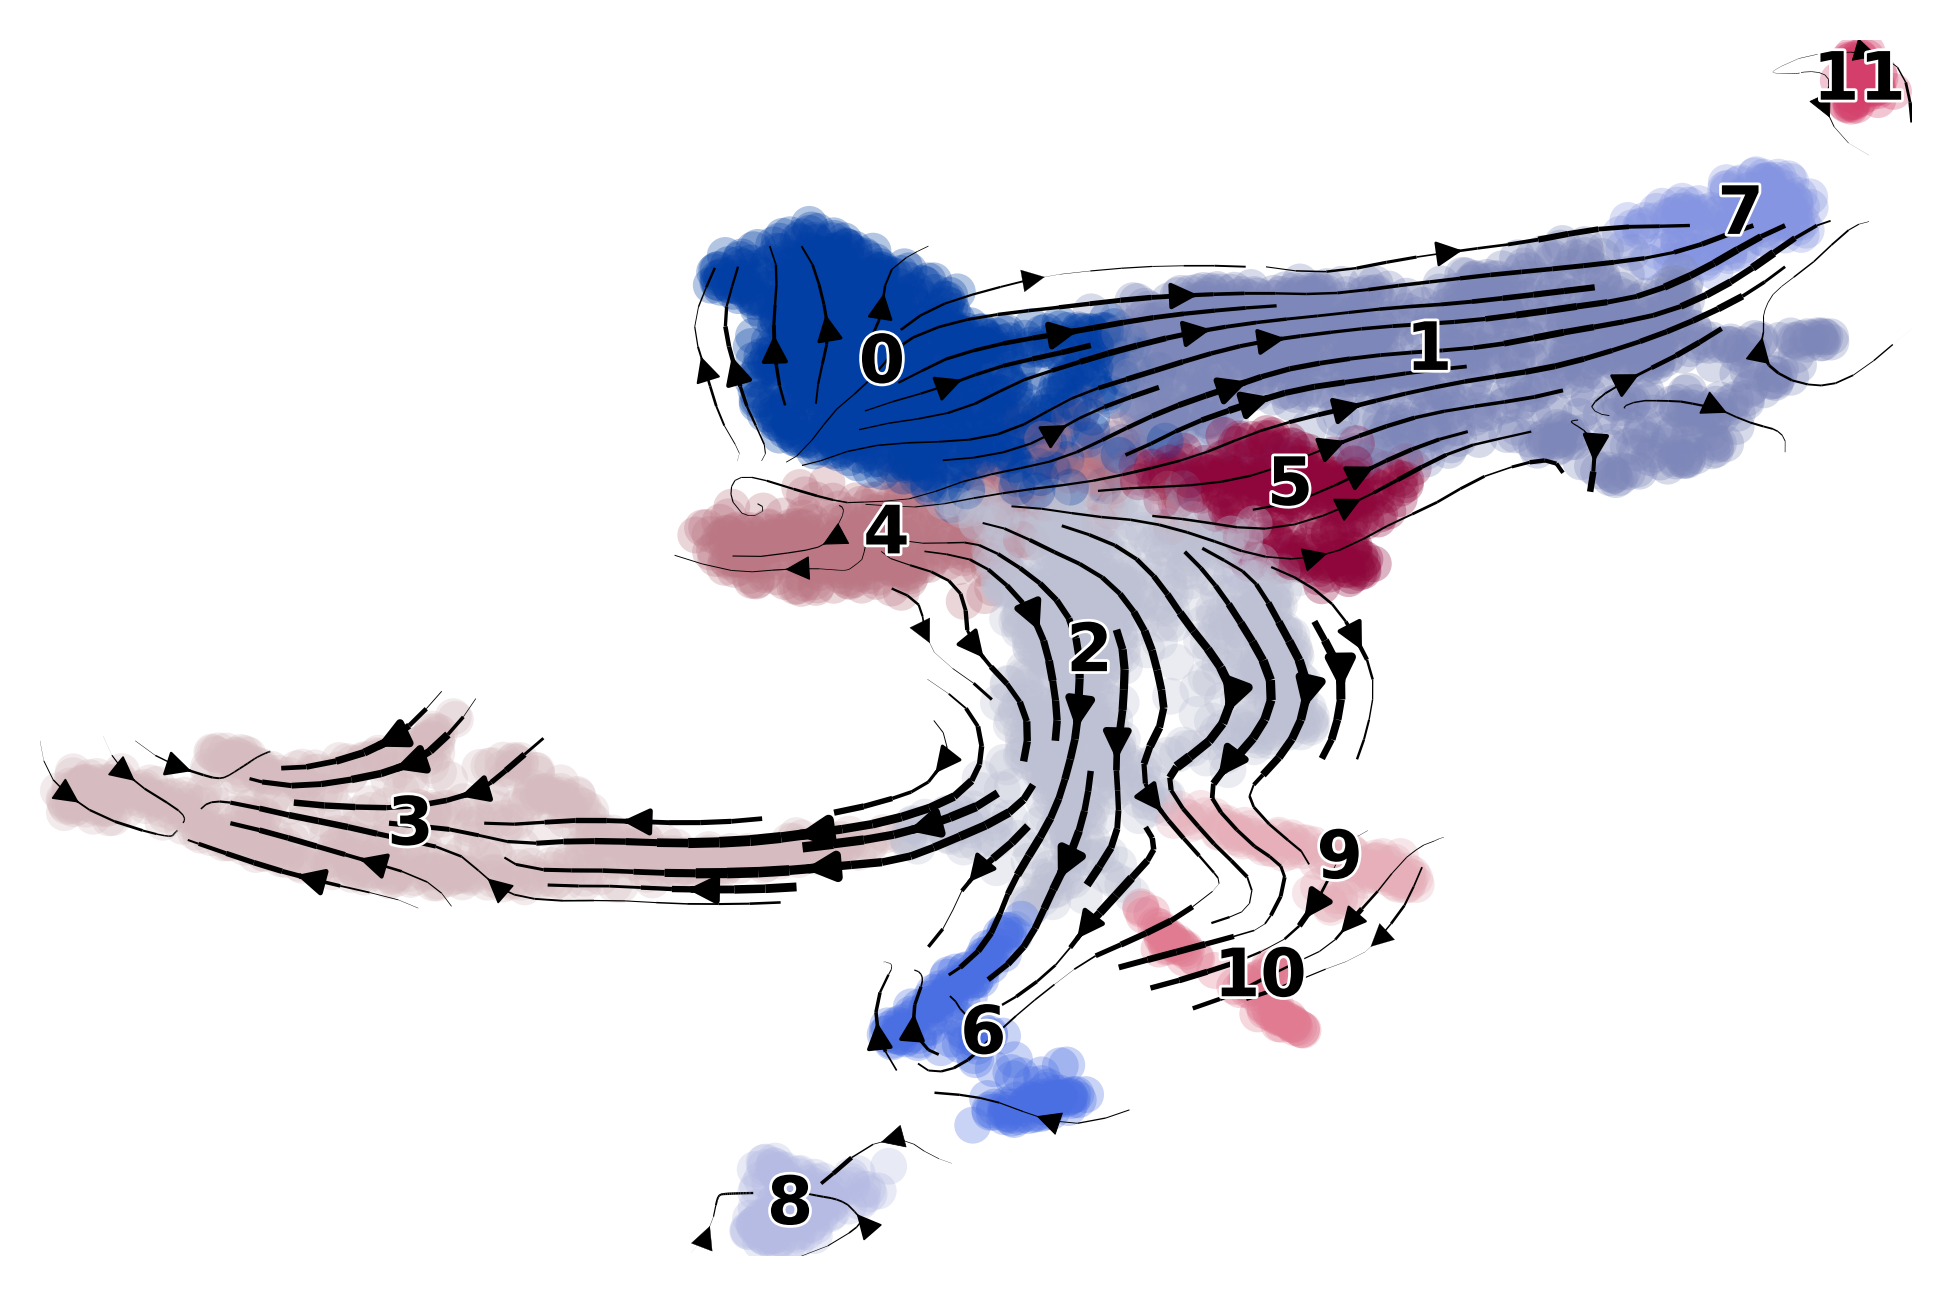

In [17]:
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=200,color="leiden", title="",
                                 #save="plus345_2_subset_velocity_stream_grey.svg"
                                )

computing velocity embedding


/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


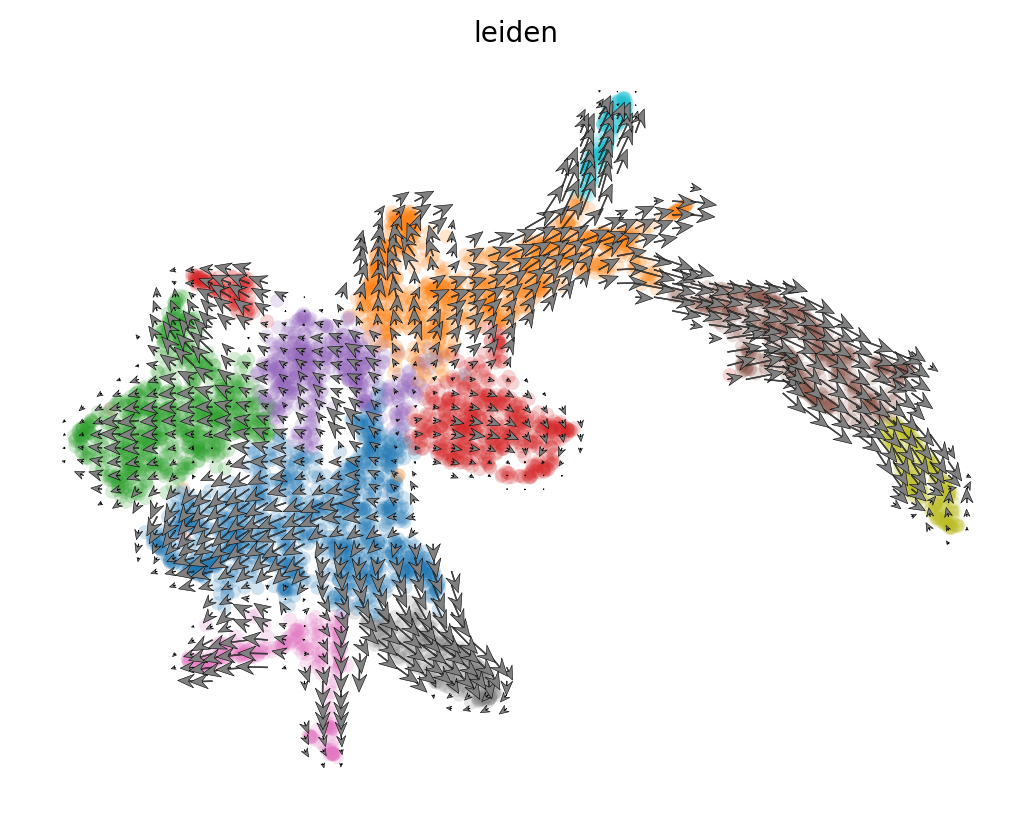

/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/blue/square.t/miniconda3/envs/scvelo_033_scrublet/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


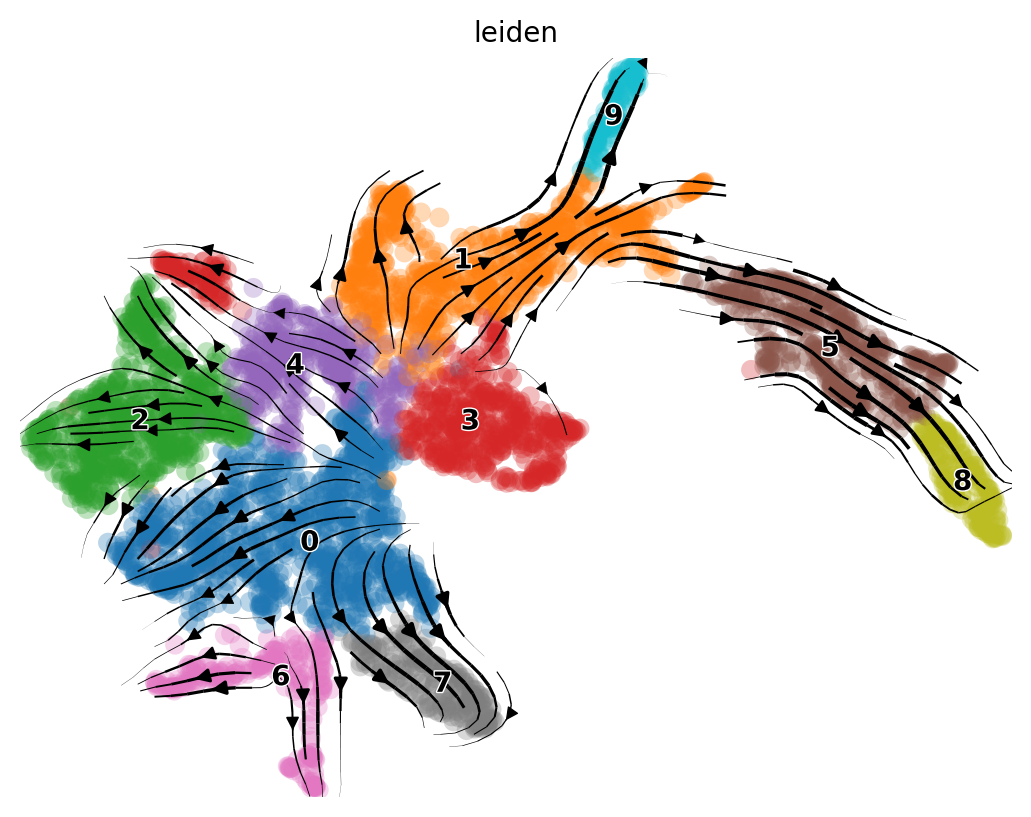

In [6]:
scv.pl.velocity_embedding_grid(
        adata_velocity,
        basis="umap",
        arrow_length=3,
        density=1,
        arrow_size=3,dpi=200,color="leiden",
        #save="plus345_2_subset_velocity_stream_grey.svg"
)
scv.pl.velocity_embedding_stream(adata_velocity, basis='umap',dpi=200,color="leiden",
                                 #save="plus345_2_subset_velocity_stream_grey.svg"
                                )

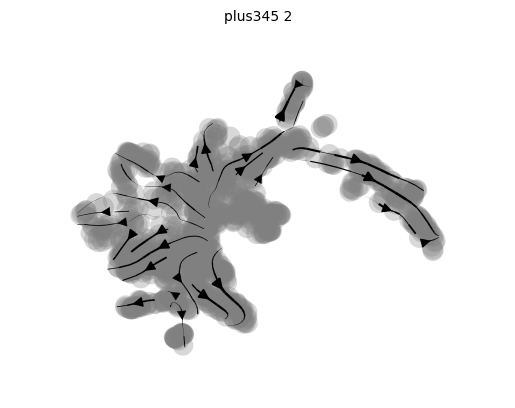

In [9]:
#velocity by sample
adata_sample = adata_velocity[adata_velocity.obs["sample"] == "p5_1"].copy()

scv.pl.velocity_embedding_stream(
    adata_sample,
    basis="umap",
    #arrow_length=2,
    density=.85,
    title="plus345_2",
    arrow_size=1.5,
    #color="leiden",
    #palette=glasbey_clean_24,
    add_margin=0.2,
    #save="plus345_2_subset_velocity_stream_grey.svg"
)